# Immunization DSS: data to trained forecasting models (Colab pipeline)

One cell per stage of `docs/12_DATA_TO_TRAINING_PIPELINE.md`. Every stage calls the same `immdss` command that is
versioned in the repository, so the notebook holds no model code of its own. All model fitting happens here, on
Colab, never on the development laptop (D-14).

**Before running:** Runtime > Change runtime type > GPU (T4 is enough). Then Runtime > Run all.

| Stage | Cell | Output (under `/content/immunization-dss/results/`) |
|---|---|---|
| 0 | Settings, environment, clone at a fixed commit, install, tests | `environment.txt` |
| 2, 3 | Generate the synthetic data with seed 42 and validate it; check it is byte-identical to the evidence run | `data/synthetic/<run_id>/` |
| 4 | EDA of the generated data | `eda/` |
| 7, 8 | Build and clean the weekly training series; series EDA | `series/`, `series_eda/` |
| 9, 10 | Rolling-origin backtest: baselines, then B1, B2, SARIMA and GRU | `backtest_baselines/`, `backtest/` |
| 11 | Compare models, per vaccine, select the best per series (D-21), bias against true demand | `backtest/` |
| 12 | Fit the selected models on all weeks, forecast the next 4 weeks | `backtest/final_forecasts.csv`, `backtest/gru.keras` |
| - | Package everything for download | `results_<run_id>_<commit>.zip` |

The data is fully synthetic (D-02). No file is uploaded: the data is regenerated here from the seed and checked
against the reference hashes in `analytics/configs/evidence_hashes.json`.

## 0. Settings

In [10]:
REPO_URL = "https://github.com/shantelle04/immunization-dss.git"
REF = "phase/4-models"  # branch, tag or commit; use a tag (for example p2) for a result cited in the thesis
SEED = 42
MODELS = "b1,b2,sarima,gru"
WORKDIR = "/content/immunization-dss"

### Environment and GPU

In [11]:
import sys, subprocess
print(sys.version)
assert sys.version_info >= (3, 12), "the analytics package needs Python 3.12 or later"
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"],
                     capture_output=True, text=True).stdout or "No GPU: Runtime > Change runtime type > GPU")

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
name, memory.total [MiB]
Tesla T4, 15360 MiB



### Clone the repository at a fixed commit and install the analytics package

In [12]:
import os
if not os.path.exists(WORKDIR):
    !git clone --quiet {REPO_URL} {WORKDIR}
%cd {WORKDIR}
!git fetch --quiet origin {REF} && git checkout --quiet --detach FETCH_HEAD
HEADS = !git rev-parse HEAD FETCH_HEAD
assert len(HEADS) == 2 and HEADS[0] == HEADS[1], f"checkout of {REF} failed: {HEADS}"
COMMIT = HEADS[0][:7]
print("commit", COMMIT)
!pip install --quiet -e "analytics[dev,train]"
!mkdir -p results && pip freeze > results/environment.txt

/content/immunization-dss
commit ff1ff0b
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 97.5 MB/s eta 0:00:00
  Building editable for immdss-analytics (pyproject.toml) ... done


### Unit tests of the pipeline code (series, cleaning, splits, metrics, baselines, selection)

In [13]:
!python -m pytest -q analytics/tests

.................s.............................                          [100%]
46 passed, 1 skipped in 20.26s


## 2 and 3. Generate and validate the synthetic data

`immdss simulate` rebuilds the evidence run from seed 42 (about 2 to 4 minutes) and runs the 11 validation checks.
The next cell compares every file hash with the reference. A mismatch means a library version changed the numbers:
the run is still valid but is a different run, and must be logged as such, not cited as the evidence run.

In [14]:
!immdss simulate --seed {SEED}
RUN_ID = open("analytics/configs/evidence_run.txt").read().strip()
RUN_DIR = f"data/synthetic/{RUN_ID}"
print("run", RUN_ID)

calibrated in 60s, max error 1.04 pp
engine refinement 0: max error 12.4 pp
engine refinement 1: max error 6.5 pp
engine refinement 2: max error 5.1 pp
engine refinement 3: max error 5.9 pp
engine refinement 4: max error 3.9 pp
engine refinement 5: max error 2.4 pp
engine refinement 6: max error 2.9 pp
engine refinement 7: max error 2.6 pp
engine refinement 8: max error 2.5 pp
wrote data/synthetic/sim-seed42-368707d3 in 191s
  app/facilities.csv: 12 rows
  app/antigens.csv: 7 rows
  app/schedule.csv: 16 rows
  app/sessions.csv: 17,724 rows
  app/children.csv: 35,525 rows
  app/immunization_events.csv: 499,839 rows
  app/stock_transactions.csv: 84,941 rows
  app/vaccine_lots.csv: 5,806 rows
V-01 PASS  Every file matches its manifest hash: 16 files verified
V-02 PASS  Stock conservation: opening + receipts - administered - wastage - losses = closing: 0 of 21840 facility-antigen-weeks violate it
V-03 PASS  Stock never negative: 0 negative balances
V-04 PASS  Transaction ledger sums to the

In [15]:
import json
reference = json.load(open("analytics/configs/evidence_hashes.json"))
manifest = json.load(open(f"{RUN_DIR}/manifest.json"))
assert manifest["run_id"] == reference["run_id"], "different settings: not the evidence run"
mismatched = [f for f, sha in reference["files"].items() if manifest["files"][f]["sha256"] != sha]
print("generator code identical:", manifest["code_sha256"] == reference["code_sha256"])
print("files identical to the evidence run:", len(reference["files"]) - len(mismatched), "of", len(reference["files"]))
assert not mismatched, f"differs from the evidence run: {mismatched}"
validation = json.load(open(f"{RUN_DIR}/validation_report.json"))
print("validation passed:", validation["passed"])

generator code identical: True
files identical to the evidence run: 14 of 14
validation passed: True


In [16]:
from IPython.display import Markdown, display
display(Markdown(open(f"{RUN_DIR}/validation_report.md").read()))

# Validation report: sim-seed42-368707d3

Overall: PASS

| Check | Description | Result | Detail |
|---|---|---|---|
| V-01 | Every file matches its manifest hash | PASS | 16 files verified |
| V-02 | Stock conservation: opening + receipts - administered - wastage - losses = closing | PASS | 0 of 21840 facility-antigen-weeks violate it |
| V-03 | Stock never negative | PASS | 0 negative balances |
| V-04 | Transaction ledger sums to the final closing balance | PASS | max difference 0 doses |
| V-05 | No dose before its minimum age or after its maximum age | PASS | 0 too young, 0 too old |
| V-06 | Minimum interval between doses of the same antigen respected | PASS | 0 violations |
| V-07 | No child receives the same dose twice | PASS | 0 duplicates |
| V-08 | Doses of a series are given in order | PASS | 0 out-of-order series |
| V-09 | Every event belongs to a registered child | PASS | 0 orphan events |
| V-10 | Coverage within 3.0 points of KDHS 2022 Table 11 for every antigen | PASS | largest difference 2.5 points (mr1) |
| V-11 | Stock-outs occur (the alert evaluation needs positive cases) | PASS | 2290 stock-out facility-antigen-weeks |

## coverage_vs_kdhs2022

| indicator | cohort_size | simulated_pct | kdhs_2022_pct | difference_pp |
|---|---|---|---|---|
| bcg | 5309 | 97.1 | 96.9 | 0.2 |
| opv0 | 5309 | 85.0 | 86.1 | -1.1 |
| opv1 | 5309 | 97.0 | 96.5 | 0.5 |
| opv2 | 5309 | 94.7 | 94.2 | 0.5 |
| opv3 | 5309 | 76.2 | 78.2 | -2.0 |
| penta1 | 5309 | 97.2 | 97.1 | 0.1 |
| penta2 | 5309 | 94.8 | 93.9 | 0.9 |
| penta3 | 5309 | 88.2 | 89.2 | -1.0 |
| pcv1 | 5309 | 97.1 | 96.5 | 0.6 |
| pcv2 | 5309 | 95.5 | 95.4 | 0.1 |
| pcv3 | 5309 | 91.4 | 91.2 | 0.2 |
| rota1 | 5309 | 95.9 | 96.0 | -0.1 |
| rota2 | 5309 | 91.7 | 92.3 | -0.6 |
| ipv | 5309 | 87.6 | 87.4 | 0.2 |
| mr1 | 5309 | 86.5 | 89.0 | -2.5 |
| mr2 | 5225 | 66.3 | 66.8 | -0.5 |
| zero_dose | 5309 | 2.1 | 2.1 | 0.0 |

## penta3_by_group

| group | category | n | simulated_penta3_pct | kdhs_2022_pct |
|---|---|---|---|---|
| education | none | 534 | 78.5 | 73.0 |
| education | primary | 1987 | 89.2 | 90.6 |
| education | secondary | 1866 | 88.8 | 90.6 |
| education | higher | 922 | 90.5 | 92.6 |
| wealth | lowest | 1235 | 86.4 | 85.1 |
| wealth | second | 989 | 89.7 | 92.3 |
| wealth | middle | 876 | 87.3 | 88.8 |
| wealth | fourth | 1010 | 87.6 | 90.0 |
| wealth | highest | 1199 | 90.0 | 90.4 |
| birth_order | 1 | 1648 | 89.9 | 92.0 |
| birth_order | 2-3 | 2038 | 87.9 | 89.0 |
| birth_order | 4-5 | 1058 | 88.7 | 88.9 |
| birth_order | 6+ | 565 | 83.5 | 82.5 |

## timeliness

| dose | median_days_after_recommended_age | share_within_28_days_pct |
|---|---|---|
| BCG-1 | 7.0 | 65.0 |
| PENTA-1 | 9.0 | 92.6 |
| PENTA-3 | 27.0 | 52.5 |
| MR-1 | 26.0 | 54.6 |

## stock_summary

| antigen_code | stockout_weeks | unmet_doses | administered | wasted | lost | wastage_rate_pct | wastage_rate_who_pct |
|---|---|---|---|---|---|---|---|
| BCG | 446 | 1108 | 25621 | 49239 | 120 | 65.8 | 65.8 |
| IPV | 327 | 1439 | 22928 | 960 | 40 | 4.0 | 4.2 |
| MR | 444 | 2589 | 40934 | 34836 | 190 | 46.0 | 46.1 |
| OPV | 300 | 5952 | 92884 | 5747 | 260 | 5.8 | 6.1 |
| PCV | 214 | 2976 | 74466 | 906 | 172 | 1.2 | 1.4 |
| PENTA | 254 | 3006 | 73682 | 0 | 183 | 0.0 | 0.2 |
| ROTA | 305 | 2935 | 49552 | 0 | 133 | 0.0 | 0.3 |


## 4. Exploratory data analysis of the generated data (figures F-D1 to F-D8, table T-5.1)

In [17]:
!immdss eda {RUN_DIR} --out results/eda

report: results/eda/EDA_sim-seed42-368707d3.md


# EDA evidence: sim-seed42-368707d3

Generated 2026-10-02 by `immdss eda`. Run seed 42, config hash `368707d3`, git commit `ff1ff0b1b97468b5af498590948d8308b2f9c4c8`. Validation: PASS. Each figure is followed by its data table (table alternative and evidence).

## T-5.1 Dataset description

| folder | file | rows | columns | column_names | content | use |
|---|---|---|---|---|---|---|
| app | antigens.csv | 7 | 4 | antigen_code, name, doses_per_vial, open_vial_policy | Vaccines, vial size, open-vial policy | Loaded by the application |
| app | children.csv | 35,525 | 10 | child_id, system_id, given_name, family_name, sex, date_of_birth, caregiver_name, registration_facility_code, registered_on, is_synthetic | Registered children (synthetic names, no phone numbers) | Loaded by the application |
| app | facilities.csv | 12 | 7 | facility_code, name, keph_level, ownership, county, sub_county, is_synthetic | Fictional facilities and their KEPH level | Loaded by the application |
| app | immunization_events.csv | 499,839 | 10 | event_id, child_id, dose_code, antigen_code, dose_number, given_on, facility_code, session_id, lot_number, is_synthetic | Doses given: child, dose, date, facility, session, lot | Loaded by the application |
| app | schedule.csv | 16 | 8 | dose_code, antigen_code, dose_number, contact, recommended_age_days, min_age_days, max_age_days, min_interval_days | KEPI dose rules: recommended, minimum and maximum age, minimum interval | Loaded by the application |
| app | sessions.csv | 17,724 | 5 | session_id, facility_code, date, kind, location_name | Fixed and outreach immunization sessions | Loaded by the application |
| app | stock_transactions.csv | 84,941 | 9 | transaction_id, date, facility_code, antigen_code, lot_number, kind, quantity_doses, session_id, is_synthetic | Stock ledger: opening balances, receipts, issues, wastage, losses | Loaded by the application |
| app | vaccine_lots.csv | 5,806 | 3 | lot_number, antigen_code, first_received | Vaccine lots and first receipt date | Loaded by the application |
| imports | import_dirty_truth.csv | 120 | 3 | file, row_index, defect | Answer key: row and defect type for every planted defect | Import-cleaning test only |
| imports | import_immunizations_dirty.csv | 617 | 6 | child_system_id, date_of_birth, dose_code, given_on, facility_code, lot_number | Immunization import sample with planted defects | Import-cleaning test only |
| imports | import_stock_dirty.csv | 200 | 6 | date, facility_code, antigen_code, lot_number, kind, quantity_doses | Stock import sample with planted defects | Import-cleaning test only |
| truth | children_truth.csv | 36,431 | 16 | child_id, home_facility_code, date_of_birth, sex, education, wealth, birth_order, residence, attends_outreach, risk_log_odds, entered_care, first_contact, dropout_after_contact, moved_to_facility_code, move_from_contact, registered | Every child born (including never-registered zero-dose children), background, dropout | Evaluation only, never loaded |
| truth | stockout_turned_away.csv | 20,005 | 4 | child_id, dose_code, date, facility_code | Every dose refused because of a stock-out | Evaluation only, never loaded |
| truth | weekly_stock.csv | 21,840 | 14 | facility_code, antigen_code, week_start, opening_doses, receipts_doses, requested_doses, administered_doses, unmet_doses, vials_opened, wastage_doses, loss_doses, in_disruption, closing_doses, stockout | Facility x antigen x week: true demand, administered, unmet, wastage, stock-out flag | Evaluation only, never loaded |

## F-D1

![F-D1_calibration_vs_kdhs2022.png](F-D1_calibration_vs_kdhs2022.png)

| indicator | cohort_size | simulated_pct | kdhs_2022_pct | difference_pp |
|---|---|---|---|---|
| BCG | 5309 | 97.1 | 96.9 | 0.2 |
| OPV0 | 5309 | 85.0 | 86.1 | -1.1 |
| OPV1 | 5309 | 97.0 | 96.5 | 0.5 |
| OPV2 | 5309 | 94.7 | 94.2 | 0.5 |
| OPV3 | 5309 | 76.2 | 78.2 | -2.0 |
| Penta1 | 5309 | 97.2 | 97.1 | 0.1 |
| Penta2 | 5309 | 94.8 | 93.9 | 0.9 |
| Penta3 | 5309 | 88.2 | 89.2 | -1.0 |
| PCV1 | 5309 | 97.1 | 96.5 | 0.6 |
| PCV2 | 5309 | 95.5 | 95.4 | 0.1 |
| PCV3 | 5309 | 91.4 | 91.2 | 0.2 |
| Rota1 | 5309 | 95.9 | 96.0 | -0.1 |
| Rota2 | 5309 | 91.7 | 92.3 | -0.6 |
| IPV | 5309 | 87.6 | 87.4 | 0.2 |
| MR1 | 5309 | 86.5 | 89.0 | -2.5 |
| MR2 | 5225 | 66.3 | 66.8 | -0.5 |
| Zero-dose | 5309 | 2.1 | 2.1 | 0.0 |

## F-D2

![F-D2_dropout_by_level.png](F-D2_dropout_by_level.png)

| facility_level | registered_12_23m | penta1 | penta3 | mr1 | dropout_penta1_penta3_pct | dropout_penta1_mr1_pct |
|---|---|---|---|---|---|---|
| Dispensary | 814 | 804 | 715 | 707 | 11.1 | 12.1 |
| Health centre | 1763 | 1752 | 1568 | 1468 | 10.5 | 16.2 |
| Sub-county hospital | 2621 | 2604 | 2400 | 2416 | 7.8 | 7.2 |
| All facilities | 5198 | 5160 | 4683 | 4591 | 9.2 | 11.0 |

## F-D3

![F-D3_timeliness.png](F-D3_timeliness.png)

| dose | doses_given | median_days_late | p75_days_late | p90_days_late | within_28_days_pct |
|---|---|---|---|---|---|
| BCG | 34916 | 7.0 | 51.0 | 78.0 | 65.0 |
| Penta1 | 34574 | 9.0 | 15.0 | 25.0 | 92.6 |
| Penta3 | 30200 | 27.0 | 51.0 | 192.0 | 52.5 |
| MR1 | 28245 | 26.0 | 47.0 | 90.0 | 54.6 |

## F-D4

![F-D4_weekly_demand_stockouts.png](F-D4_weekly_demand_stockouts.png)

| facility | antigen | weeks | stockout_weeks | requested_doses | administered_doses | unmet_doses |
|---|---|---|---|---|---|---|
| SYN-D03 | PENTA | 104 | 13 | 1225 | 1129 | 96 |
| SYN-D03 | MR | 104 | 24 | 687 | 645 | 42 |
| SYN-S03 | PENTA | 104 | 11 | 5109 | 4850 | 259 |
| SYN-S03 | MR | 104 | 26 | 3295 | 2792 | 503 |

## F-D5

![F-D5_stock_vs_minimum.png](F-D5_stock_vs_minimum.png)

| facility | antigen | weeks_below_minimum | stockout_weeks | disruption_weeks | median_closing_doses |
|---|---|---|---|---|---|
| SYN-H01 | OPV | 119 | 27 | 8 | 68.5 |
| SYN-H01 | MR | 109 | 35 | 6 | 40.0 |

## F-D6

![F-D6_registry_by_facility.png](F-D6_registry_by_facility.png)

| facility_code | name | keph_level | registered_children |
|---|---|---|---|
| SYN-D04 | Kasanga Dispensary | Dispensary | 1541 |
| SYN-D03 | Mugathi Dispensary | Dispensary | 1332 |
| SYN-D01 | Olomani Dispensary | Dispensary | 1132 |
| SYN-D02 | Chimani Dispensary | Dispensary | 924 |
| SYN-D05 | Gamani Dispensary | Dispensary | 735 |
| SYN-H02 | Semani Health Centre | Health centre | 3699 |
| SYN-H01 | Ndotamu Health Centre | Health centre | 3001 |
| SYN-H03 | Chinyeri Health Centre | Health centre | 2690 |
| SYN-H04 | Watamu Health Centre | Health centre | 2262 |
| SYN-S01 | Kirura Sub-County Hospital | Sub-county hospital | 6873 |
| SYN-S03 | Nyatamu Sub-County Hospital | Sub-county hospital | 6032 |
| SYN-S02 | Nyabiru Sub-County Hospital | Sub-county hospital | 5304 |

## F-D7

![F-D7_import_defects.png](F-D7_import_defects.png)

| file | defect | rows | share_of_file_pct |
|---|---|---|---|
| immunizations | DUPLICATE_ROW | 17 | 2.8 |
| immunizations | MALFORMED_DATE | 14 | 2.3 |
| immunizations | MISSING_CHILD_ID | 14 | 2.3 |
| immunizations | DATE_BEFORE_BIRTH | 13 | 2.1 |
| immunizations | UNKNOWN_DOSE | 13 | 2.1 |
| immunizations | UNKNOWN_FACILITY | 11 | 1.8 |
| immunizations | FUTURE_DATE | 8 | 1.3 |
| stock | NON_NUMERIC_QUANTITY | 11 | 5.5 |
| stock | UNKNOWN_ANTIGEN | 9 | 4.5 |
| stock | NEGATIVE_RECEIPT | 6 | 3.0 |
| stock | MALFORMED_DATE | 4 | 2.0 |

## F-D8

![F-D8_penta3_by_subgroup.png](F-D8_penta3_by_subgroup.png)

| group | category | n | simulated_penta3_pct | kdhs_2022_pct | difference_pp |
|---|---|---|---|---|---|
| education | none | 534 | 78.5 | 73.0 | 5.5 |
| education | primary | 1987 | 89.2 | 90.6 | -1.4 |
| education | secondary | 1866 | 88.8 | 90.6 | -1.8 |
| education | higher | 922 | 90.5 | 92.6 | -2.1 |
| wealth | lowest | 1235 | 86.4 | 85.1 | 1.3 |
| wealth | second | 989 | 89.7 | 92.3 | -2.6 |
| wealth | middle | 876 | 87.3 | 88.8 | -1.5 |
| wealth | fourth | 1010 | 87.6 | 90.0 | -2.4 |
| wealth | highest | 1199 | 90.0 | 90.4 | -0.4 |
| birth_order | 1 | 1648 | 89.9 | 92.0 | -2.1 |
| birth_order | 2-3 | 2038 | 87.9 | 89.0 | -1.1 |
| birth_order | 4-5 | 1058 | 88.7 | 88.9 | -0.2 |
| birth_order | 6+ | 565 | 83.5 | 82.5 | 1.0 |


results/eda/F-D1_calibration_vs_kdhs2022.png


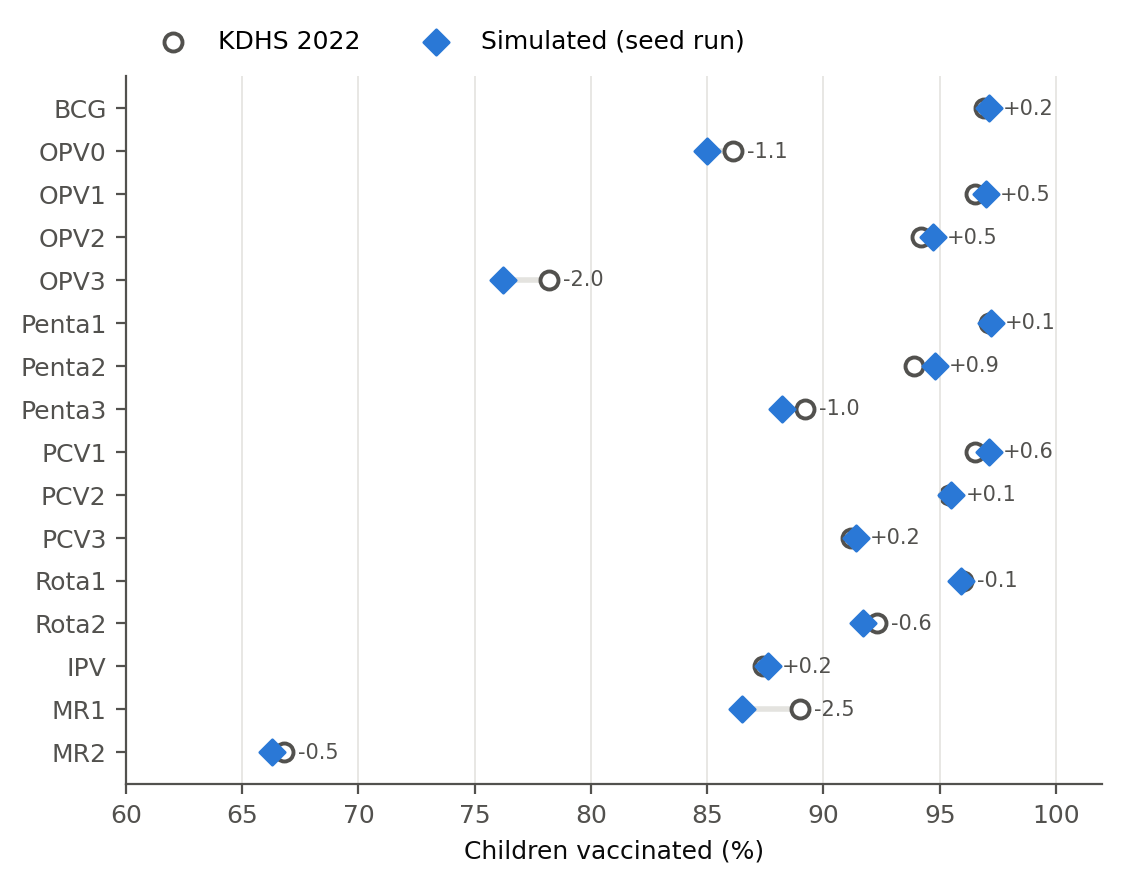

results/eda/F-D2_dropout_by_level.png


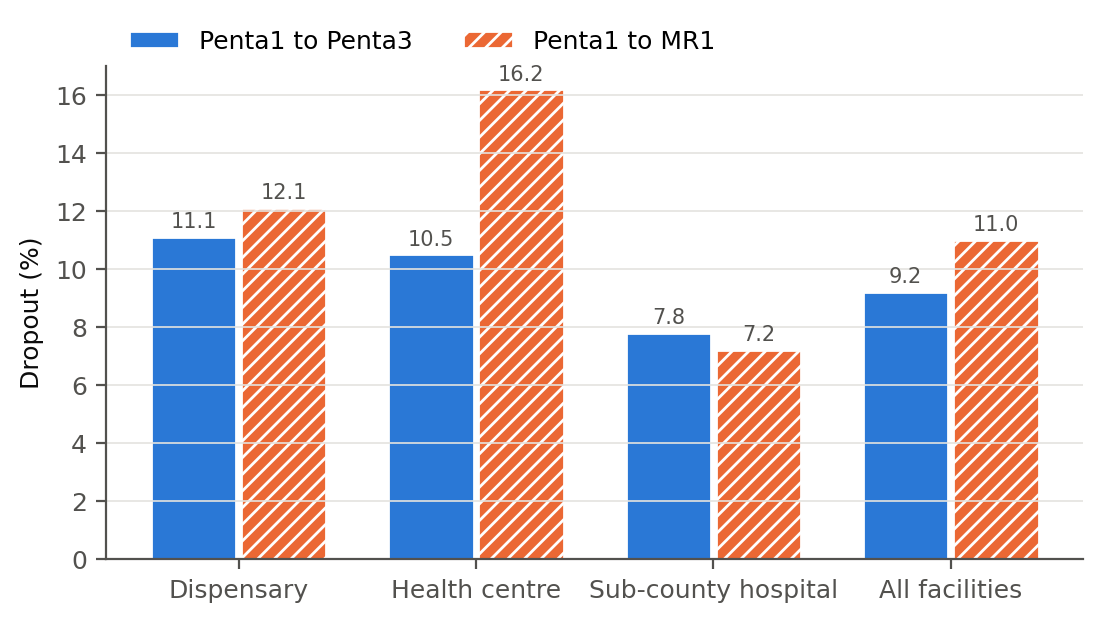

results/eda/F-D3_timeliness.png


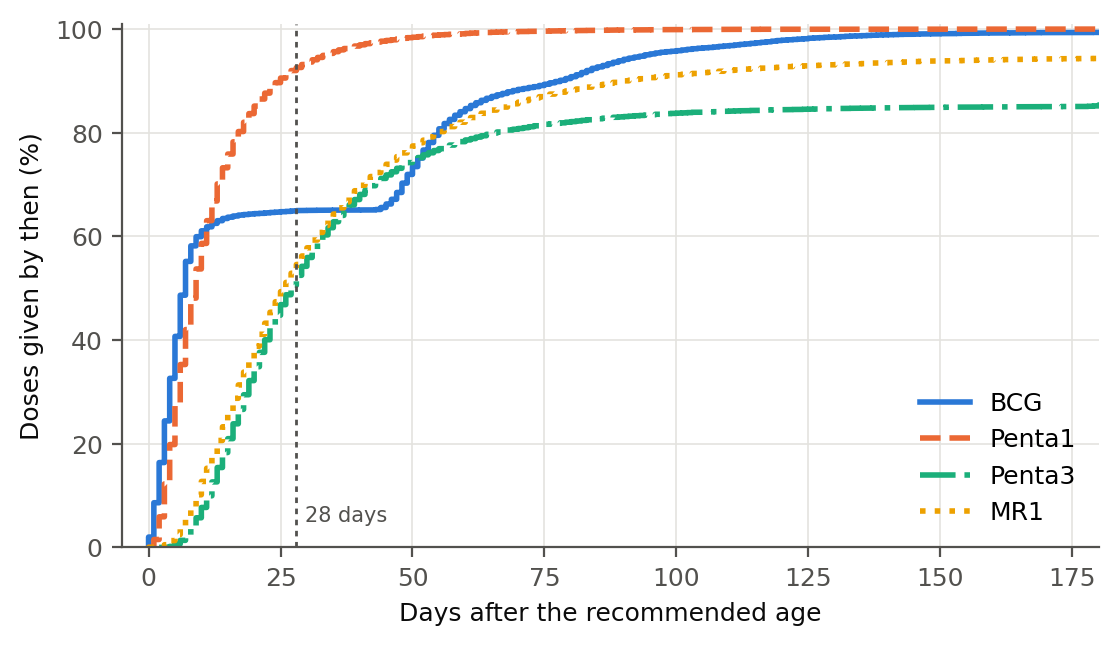

results/eda/F-D4_weekly_demand_stockouts.png


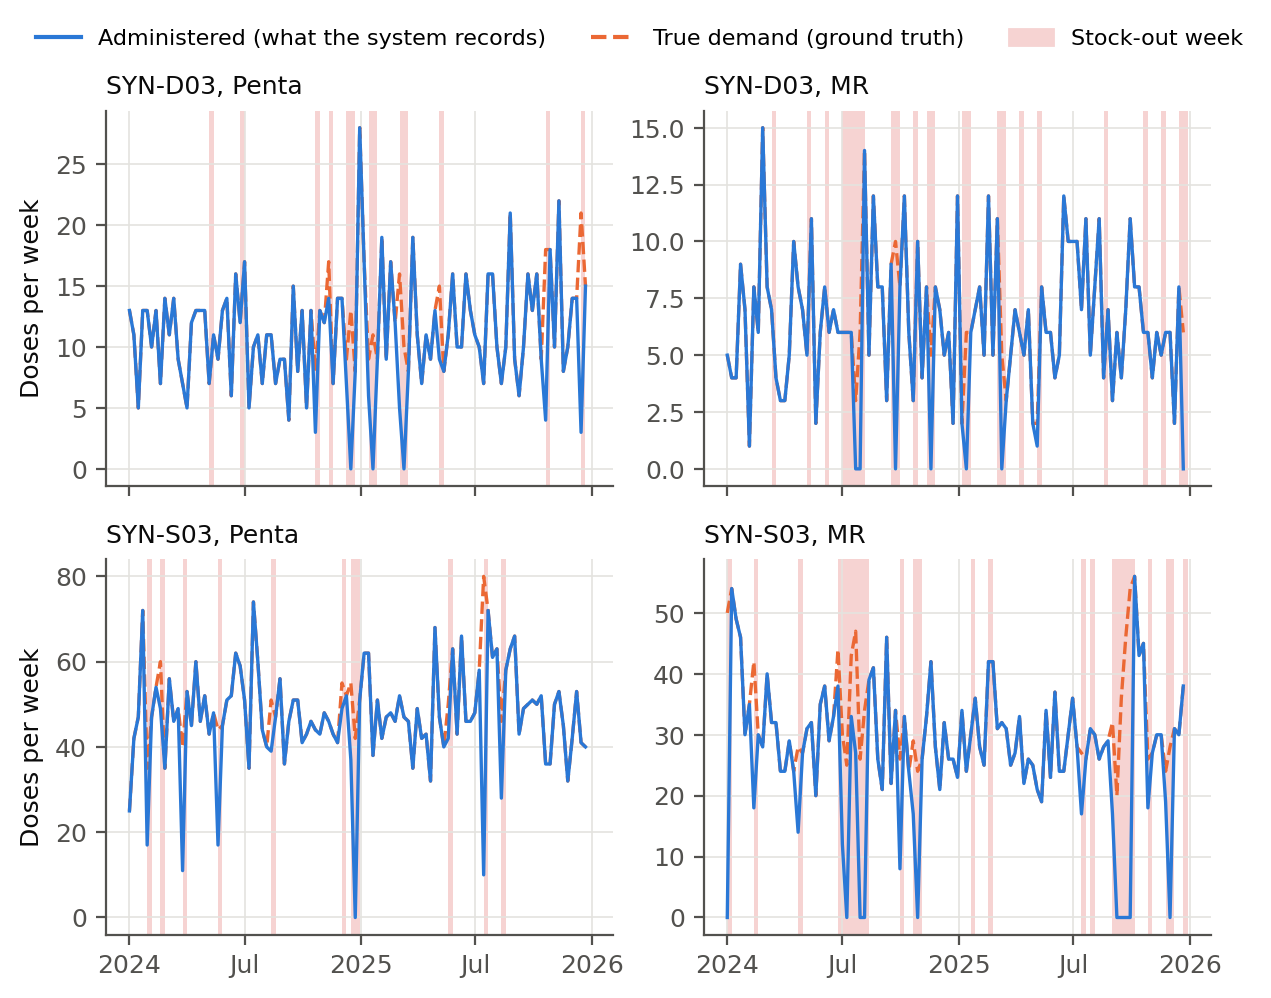

results/eda/F-D5_stock_vs_minimum.png


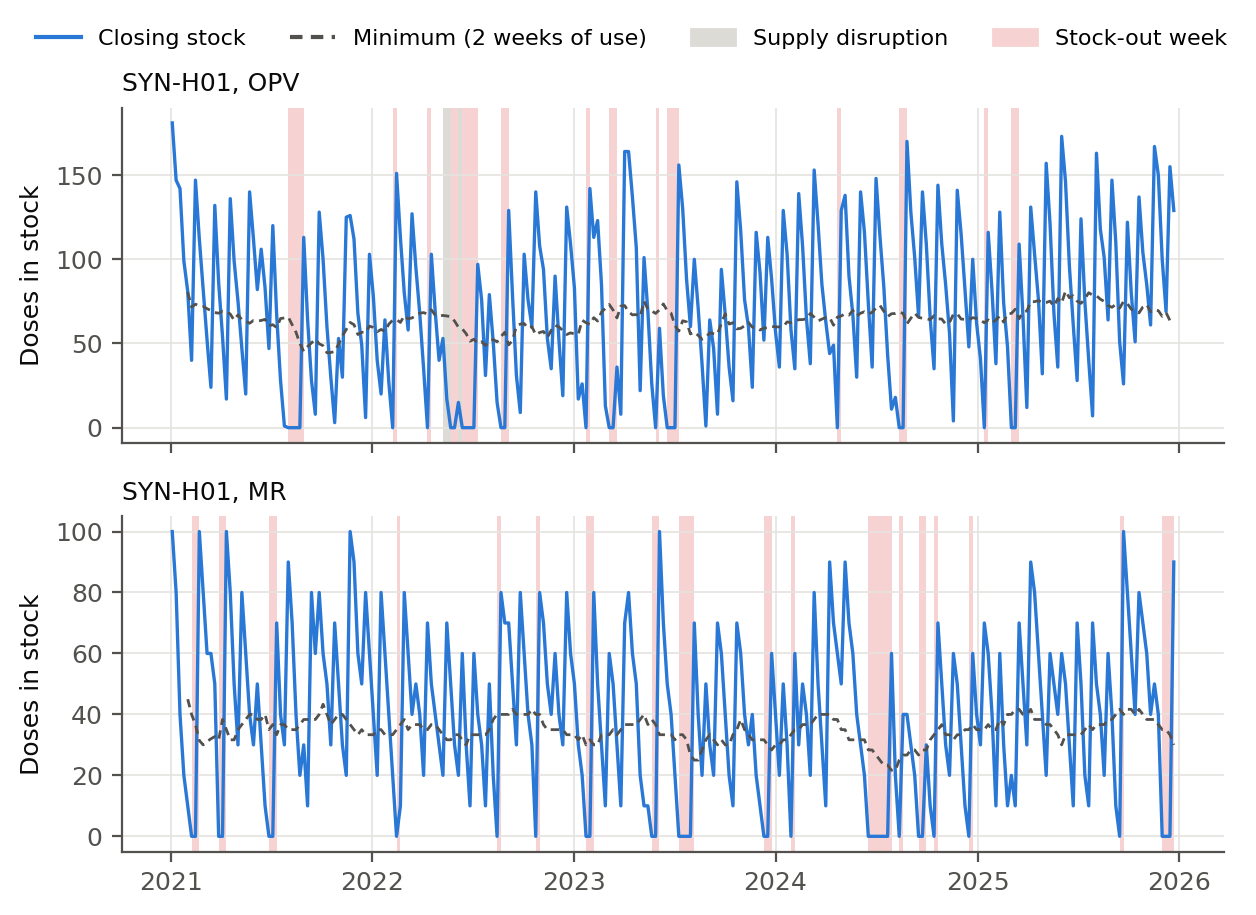

results/eda/F-D6_registry_by_facility.png


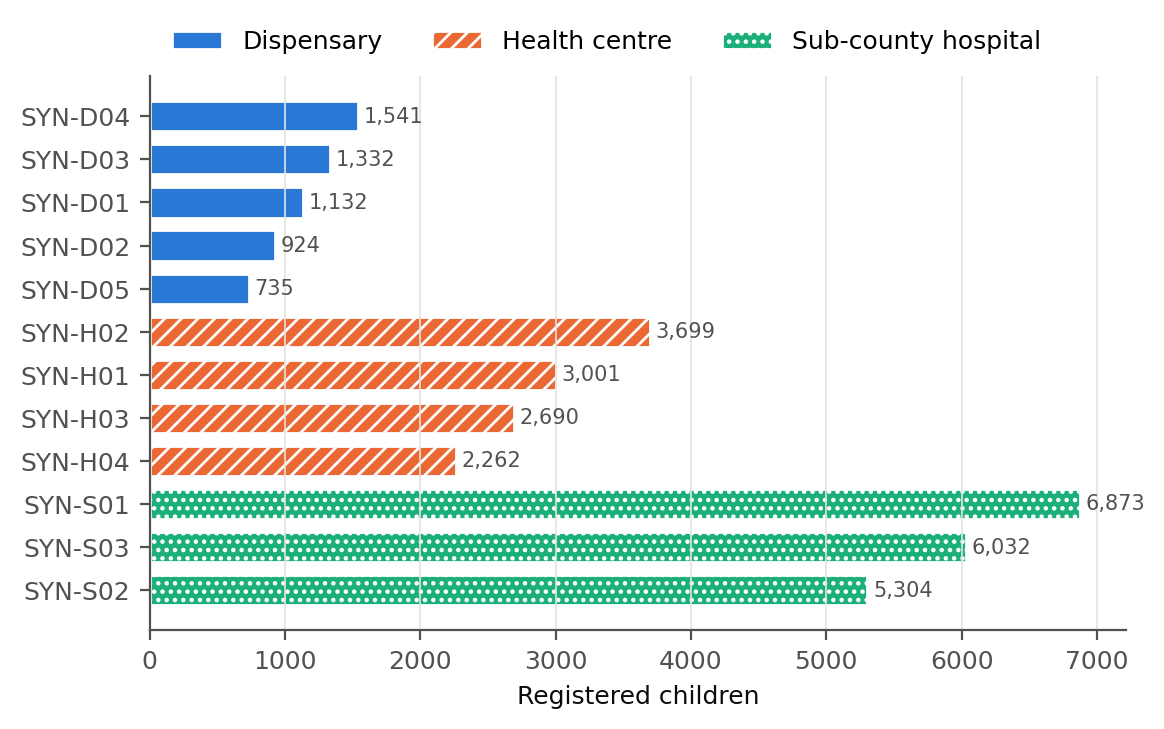

results/eda/F-D7_import_defects.png


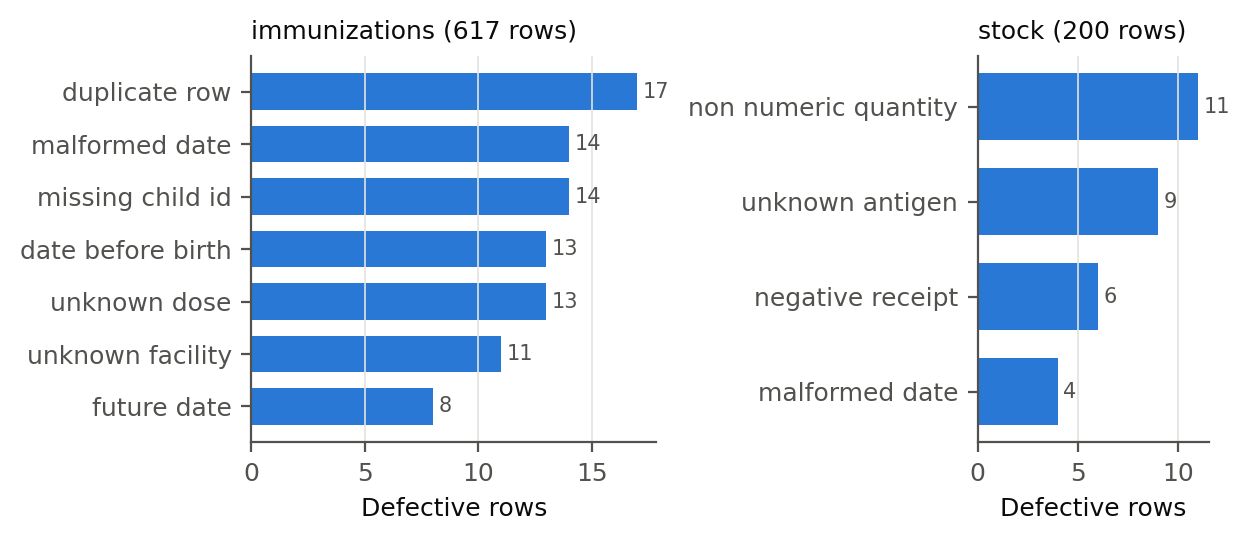

results/eda/F-D8_penta3_by_subgroup.png


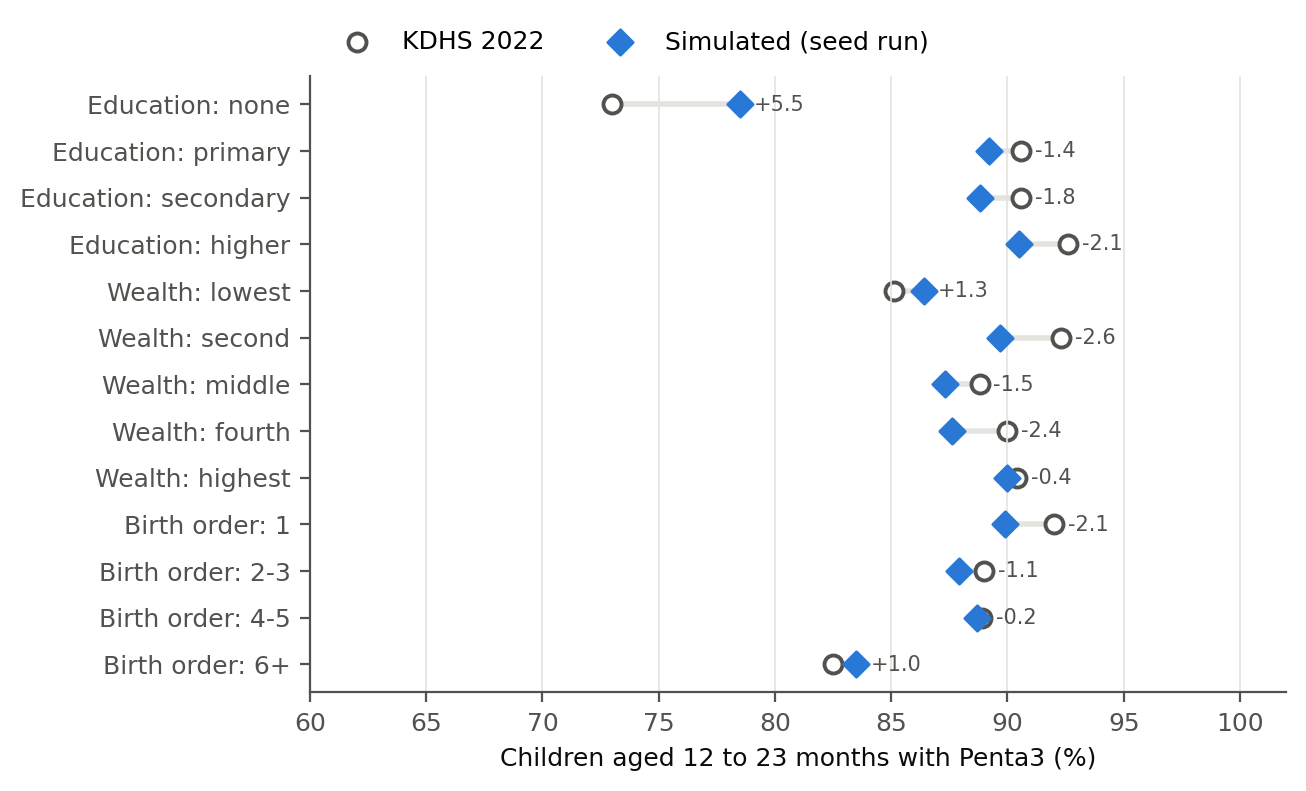

In [18]:
import glob
from IPython.display import Image
display(Markdown(open(f"results/eda/EDA_{RUN_ID}.md").read()))
for png in sorted(glob.glob("results/eda/F-D*.png")):
    print(png)
    display(Image(png, width=900))

## 7 and 8. Build and clean the weekly training series

Only issue transactions from `app/stock_transactions.csv` are used (what a real clinic system records); `truth/` is
not read. Rules T-01 (a week without issues is 0), T-02 (stock window only) and T-03 (stock-out weeks flagged from
the ledger balance).

In [19]:
!immdss build-series {RUN_DIR} --out results/series
SERIES = f"results/series/{RUN_ID}/weekly_issues.csv"
series_manifest = json.load(open(f"results/series/{RUN_ID}/series_manifest.json"))
print("series identical to the reference:", series_manifest["sha256"] == reference["weekly_issues_sha256"])

{
  "run_id": "sim-seed42-368707d3",
  "source": "app/stock_transactions.csv (issues only; truth/ not read)",
  "series": 84,
  "weeks": 260,
  "first_week": "2021-01-04",
  "last_week": "2025-12-22",
  "stockout_flagged_weeks": 1635,
  "zero_issue_weeks": 799,
  "sha256": "279617cf49eefa40473a8cb2873f4357238fd44848f791babf1459887bd9dc2b"
}
series identical to the reference: True


### Series EDA: level, zeros, stock-outs, seasonality and autocorrelation per vaccine

,series,mean_weekly_doses,share_zero_weeks,share_stockout_weeks,acf_lag1,acf_lag4,acf_lag52
antigen_code,,,,,,,
BCG,12,8.212,0.057,0.102,0.030,0.043,0.080
IPV,12,7.349,0.060,0.069,0.058,0.062,0.204
MR,12,13.120,0.046,0.099,0.169,0.013,0.132
OPV,12,29.771,0.034,0.062,0.111,0.103,-0.007
PCV,12,23.867,0.015,0.054,0.060,0.188,0.150
PENTA,12,23.616,0.016,0.066,0.077,0.300,0.264
ROTA,12,15.882,0.027,0.073,0.082,0.284,0.152


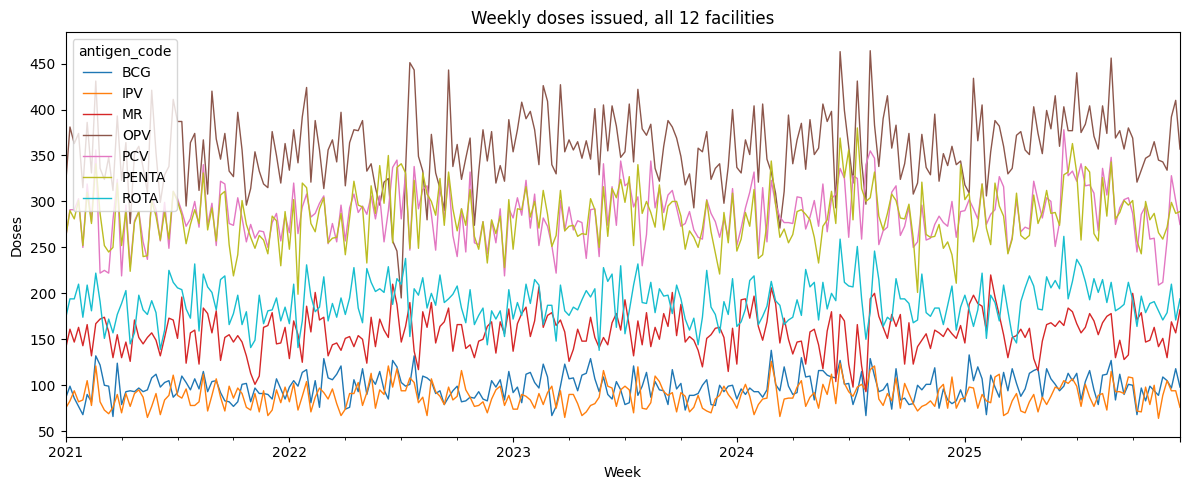

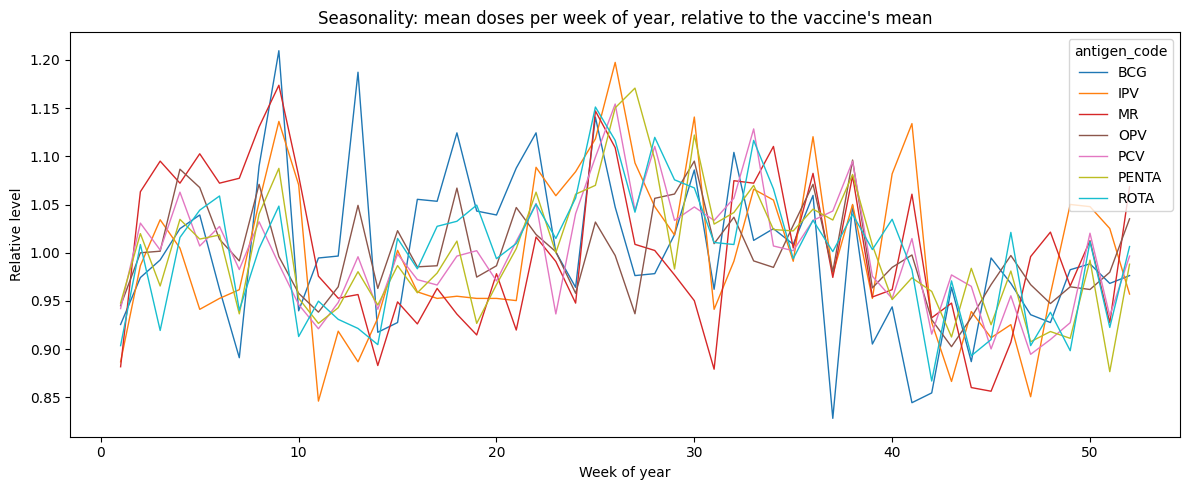

In [20]:
import pandas as pd, matplotlib.pyplot as plt
os.makedirs("results/series_eda", exist_ok=True)
s = pd.read_csv(SERIES, parse_dates=["week_start"])
summary = s.groupby("antigen_code").agg(
    series=("facility_code", "nunique"),
    mean_weekly_doses=("issued", "mean"),
    share_zero_weeks=("issued", lambda x: (x == 0).mean()),
    share_stockout_weeks=("stockout_flag", "mean"),
).round(3)
acf = {}
for ant, g in s.groupby("antigen_code"):
    total = g.groupby("week_start")["issued"].sum()
    acf[ant] = {f"acf_lag{l}": round(total.autocorr(l), 3) for l in (1, 4, 52)}
summary = summary.join(pd.DataFrame(acf).T)
summary.to_csv("results/series_eda/T-M1_series_summary.csv")
display(summary)

total = s.pivot_table(index="week_start", columns="antigen_code", values="issued", aggfunc="sum")
ax = total.plot(figsize=(12, 5), colormap="tab10", linewidth=1)
ax.set(title="Weekly doses issued, all 12 facilities", xlabel="Week", ylabel="Doses")
plt.tight_layout(); plt.savefig("results/series_eda/F-M1_weekly_issues_by_vaccine.png", dpi=150); plt.show()

s["week_of_year"] = s["week_start"].dt.isocalendar().week.clip(upper=52)
seasonal = s.groupby(["week_of_year", "antigen_code"])["issued"].mean().unstack()
ax = (seasonal / seasonal.mean()).plot(figsize=(12, 5), colormap="tab10", linewidth=1)
ax.set(title="Seasonality: mean doses per week of year, relative to the vaccine's mean", xlabel="Week of year",
       ylabel="Relative level")
plt.tight_layout(); plt.savefig("results/series_eda/F-M2_seasonality.png", dpi=150); plt.show()

## 9 and 10. Rolling-origin backtest

Six origins of 4 weeks cover the last 24 weeks. At each origin a model is fitted only on the weeks before it and
forecasts the next 4 (no test week is ever in a training window; the code asserts it). First the two baselines as a
quick check, then every model, which is the run that counts.

In [21]:
!immdss backtest {RUN_DIR} --series {SERIES} --models b1,b2 --seed {SEED} --out results/backtest_baselines

b1: 0.1s
b2: 0.1s
2026-10-02 12:56:23.095035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
model  series  mean_mase  median_mase  share_beating_naive  mean_mae  mean_smape  coverage80
   b2      84     0.7657       0.7244               0.9048    4.6885      0.3750      0.8115
   b1      84     0.9504       0.9342               0.6429    5.8646      0.4927      0.8418


In [22]:
%%time
!immdss backtest {RUN_DIR} --series {SERIES} --models {MODELS} --seed {SEED} --out results/backtest

b1: 0.1s
b2: 0.1s
sarima: 848.9s
2026-10-02 13:10:41.512785: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-02 13:10:45.236963: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790946645.238450    3883 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-10-02 13:10:47.067166: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:v

## 11. Compare the models and select the best per series

MASE under 1 means better than the seasonal naive forecast (doc 05). Selection rule D-21: the GRU where a series has
at least 104 training weeks and the GRU beats B1; otherwise SARIMA; otherwise the better baseline. `truth_bias`
compares forecasts with the true demand from `truth/`, after forecasting, for evaluation only.

,model,series,mean_mase,median_mase,share_beating_naive,mean_mae,mean_smape,coverage80
0,gru,84,0.6765,0.6358,0.9643,4.1078,0.3407,0.7862
1,sarima,84,0.6811,0.6398,0.9643,4.1713,0.3384,0.8442
2,b2,84,0.7657,0.7244,0.9048,4.6885,0.3750,0.8115
3,b1,84,0.9504,0.9342,0.6429,5.8646,0.4927,0.8418


,antigen_code,model,series,mean_mase,median_mase,share_beating_naive,mean_mae,mean_smape,coverage80
0,BCG,sarima,12,0.6870,0.6814,1.0000,2.5042,0.4326,0.8472
1,BCG,gru,12,0.6993,0.7018,1.0000,2.5745,0.4500,0.7813
2,BCG,b2,12,0.7896,0.7917,1.0000,2.8854,0.4829,0.8125
3,BCG,b1,12,0.9233,0.8775,0.8333,3.4896,0.5891,0.8403
4,IPV,gru,12,0.7721,0.7172,0.9167,2.9062,0.4785,0.7882
5,IPV,sarima,12,0.7754,0.7217,0.9167,2.9323,0.4742,0.8056
6,IPV,b2,12,0.9240,0.8774,0.7500,3.4705,0.5315,0.7431
7,IPV,b1,12,1.0081,0.9746,0.5833,3.5000,0.6409,0.8229
8,MR,sarima,12,0.6866,0.6464,0.9167,3.7884,0.3833,0.8194
9,MR,gru,12,0.6953,0.6606,0.9167,3.8104,0.3895,0.8160


,model,reason,series
0,gru,GRU beats seasonal naive with enough history,80
1,sarima,fallback: SARIMA,4


,model,stockout_flag,weeks,mean_bias,mae_vs_true_demand
0,b1,False,1877,-1.100,5.617
1,b1,True,139,-2.252,5.964
2,b2,False,1877,-0.397,4.322
3,b2,True,139,-0.392,4.813
4,gru,False,1877,-1.054,3.682
5,gru,True,139,-1.329,4.045
6,sarima,False,1877,-0.951,3.767
7,sarima,True,139,-1.333,4.193


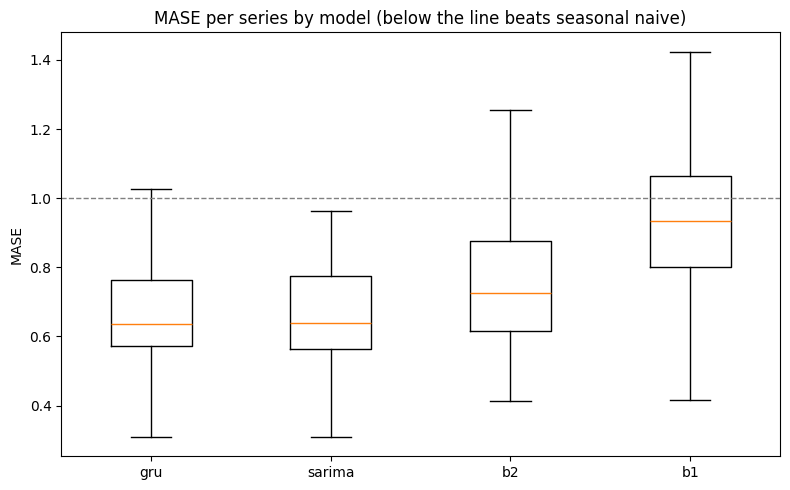

In [23]:
B = "results/backtest"
overall = pd.read_csv(f"{B}/comparison_overall.csv"); display(overall)
by_vaccine = pd.read_csv(f"{B}/comparison_by_vaccine.csv"); display(by_vaccine)
selection = pd.read_csv(f"{B}/selection.csv")
display(selection.groupby(["model", "reason"]).size().rename("series").reset_index())
if os.path.exists(f"{B}/truth_bias.csv"):
    display(pd.read_csv(f"{B}/truth_bias.csv"))

metrics = pd.read_csv(f"{B}/metrics.csv")
order = overall["model"].tolist()
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([metrics.loc[metrics.model == m, "mase"].dropna() for m in order], showfliers=False)
ax.set_xticks(range(1, len(order) + 1), order)
ax.axhline(1, color="grey", linestyle="--", linewidth=1)
ax.set(title="MASE per series by model (below the line beats seasonal naive)", ylabel="MASE")
plt.tight_layout(); plt.savefig(f"{B}/F-M3_mase_by_model.png", dpi=150); plt.show()

### Stock-out alerts against ground truth (doc 05 section 2, D-38)

One alert decision per series at each backtest origin, using the selected model's forecast and ledger data before the origin; scored against true stock-out weeks in `truth/` (evaluation only). D-07 target: recall at least 0.95, precision reported.

In [24]:
!immdss evaluate-alerts {RUN_DIR} --results results/backtest
alerts = json.load(open("results/backtest/alert_metrics.json"))
display(pd.DataFrame(alerts["sensitivity"]))
display(pd.DataFrame(alerts["by_vaccine"]).T)

{
  "decisions": 504,
  "alerts": 311,
  "true_stockout_weeks": 198,
  "true_stockout_weeks_alerted": 167,
  "recall": 0.8434,
  "precision": 0.6399,
  "precision_stockout_only": 0.3794,
  "f1": 0.7277,
  "origins_with_stockout": 146,
  "origins_with_stockout_alerted": 118,
  "mean_lead_time_weeks": 2.04,
  "buffer": 0.25,
  "by_vaccine": {
    "BCG": {
      "alerts": 56,
      "true_stockout_weeks": 47,
      "recall": 0.8936
    },
    "IPV": {
      "alerts": 47,
      "true_stockout_weeks": 33,
      "recall": 0.9091
    },
    "MR": {
      "alerts": 50,
      "true_stockout_weeks": 46,
      "recall": 0.8913
    },
    "OPV": {
      "alerts": 36,
      "true_stockout_weeks": 11,
      "recall": 0.6364
    },
    "PCV": {
      "alerts": 42,
      "true_stockout_weeks": 22,
      "recall": 0.8182
    },
    "PENTA": {
      "alerts": 42,
      "true_stockout_weeks": 21,
      "recall": 0.7619
    },
    "ROTA": {
      "alerts": 38,
      "true_stockout_weeks": 18,
      "recall

,buffer,alerts,recall,precision,f1
0,0.00,304,0.8384,0.5296,0.6491
1,0.10,305,0.8384,0.5541,0.6672
2,0.25,311,0.8434,0.6399,0.7277
3,0.50,343,0.8990,0.7784,0.8344


,alerts,true_stockout_weeks,recall
BCG,56.0,47.0,0.8936
IPV,47.0,33.0,0.9091
MR,50.0,46.0,0.8913
OPV,36.0,11.0,0.6364
PCV,42.0,22.0,0.8182
PENTA,42.0,21.0,0.7619
ROTA,38.0,18.0,0.7222


## 12. Fit the selected model per series on all weeks and forecast the next 4 weeks

In [25]:
!immdss train-final --series {SERIES} --results results/backtest --seed {SEED}
display(pd.read_csv("results/backtest/final_forecasts.csv").head(12))

2026-10-02 13:13:40.353116: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-02 13:13:44.596240: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1790946824.597770   10784 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-10-02 13:13:47.488253: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92700
2026-10-02 13:13:50.688681: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_thread

,facility_code,antigen_code,model,week_start,horizon_week,yhat,lo80,hi80,detail
0,SYN-D01,BCG,gru,2025-12-29,1,3.73,1.47,6.71,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
1,SYN-D01,BCG,gru,2026-01-05,2,3.27,1.23,6.31,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
2,SYN-D01,BCG,gru,2026-01-12,3,3.17,1.13,6.11,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
3,SYN-D01,BCG,gru,2026-01-19,4,3.37,0.97,6.09,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
4,SYN-D01,IPV,gru,2025-12-29,1,2.83,1.06,5.26,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
5,SYN-D01,IPV,gru,2026-01-05,2,2.76,0.72,5.28,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
6,SYN-D01,IPV,gru,2026-01-12,3,2.56,0.59,5.43,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
7,SYN-D01,IPV,gru,2026-01-19,4,3.06,0.62,5.65,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
8,SYN-D01,MR,gru,2025-12-29,1,6.18,3.17,10.03,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."
9,SYN-D01,MR,gru,2026-01-05,2,6.01,3.06,10.55,"{""epochs_run"": 25, ""best_val_loss"": 0.08774948..."


## Package the results

Download the zip (or copy it to Google Drive), unzip it and run `python3 scripts/dev.py forecasts --results <folder>/backtest` to use the trained models in the app (D-39). It holds the manifests, metrics, comparisons, selection, final
forecasts, the GRU file, the EDA figures and `environment.txt`. The training log entry
(`docs/logs/TRAINING_RUN_LOG.md`) is written from its `backtest/manifest.json`; no number enters a document
without it.

In [27]:
import shutil
archive = shutil.make_archive(f"/content/results_{RUN_ID}_{COMMIT}", "zip", "results")
print(archive)
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    pass

/content/results_sim-seed42-368707d3_ff1ff0b.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>